In [12]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from boulder_statistics.analysis.quick_calculate import FittingFunction
from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [13]:
manual_db = pl.read_parquet(r".database\manual_detection_database.parquet")
auto_db = dp.combined_mask_no_merge.filter(pl.col("face") == "posx").collect()

manual_db

i,j,manual_detect_boulder_id,face
i32,i32,u32,str
7661,5626,7883757,"""posx"""
7661,5627,7883757,"""posx"""
7661,5628,7883757,"""posx"""
7661,5629,7883757,"""posx"""
7661,5630,7883757,"""posx"""
…,…,…,…
40,2454,10549449,"""posx"""
40,2455,10549449,"""posx"""
40,2456,10549449,"""posx"""


In [14]:
auto_db_agg = auto_db.group_by("row_id").agg(pl.len().alias("auto_boulder_size"))
manual_db_agg = manual_db.group_by("manual_detect_boulder_id").agg(pl.len().alias("manual_boulder_size"))

db_intersections = manual_db.join(
    auto_db,
    on=["i", "j"],
    how="inner",
).select("i", "j", "lod_level", "lod_code", "row_id", "manual_detect_boulder_id")

db_intersections

i,j,lod_level,lod_code,row_id,manual_detect_boulder_id
i32,i32,u8,str,u32,u32
64,2480,0,"""""",6,10549449
64,2481,0,"""""",6,10549449
64,2482,0,"""""",6,10549449
64,2483,0,"""""",6,10549449
64,2484,0,"""""",6,10549449
…,…,…,…,…,…
7185,7880,4,"""DDDB""",3870233,6288700
7186,7879,4,"""DDDB""",3870233,6288700
7186,7880,4,"""DDDB""",3870233,6288700


In [15]:
db_intersections_agg = db_intersections.group_by("manual_detect_boulder_id", "row_id").agg(
    pl.len().alias("overlap"),
    pl.col("lod_level").first(),
    pl.col("lod_code").first()
)

db_jaccard = db_intersections_agg.join(
    auto_db_agg,
    on="row_id",
    how="left",
).join(
    manual_db_agg,
    on="manual_detect_boulder_id",
    how="left",
).with_columns(
    (
        pl.col("overlap") / (pl.col("auto_boulder_size") + pl.col("manual_boulder_size") - pl.col("overlap"))
    ).alias("Jaccard_index")
)

db_jaccard

manual_detect_boulder_id,row_id,overlap,lod_level,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index
u32,u32,u32,u8,str,u32,u32,f64
3680456,19632,71338,1,"""A""",82304,283270,0.242452
15528702,689045,88,4,"""ACDB""",88,82774,0.001063
16206714,697273,9,4,"""ACDC""",30,18901,0.000476
7193040,727406,5,2,"""AD""",2080,18253,0.000246
15528702,727436,68,2,"""AD""",6432,82774,0.000763
…,…,…,…,…,…,…,…
15675192,443816,101,4,"""ABDB""",192,217078,0.000465
15675192,475407,44,4,"""ABDD""",77,217078,0.000203
15675192,475419,12,4,"""ABDD""",44,217078,0.000055


In [16]:
db_jaccard_agg = (
    db_jaccard
    .group_by(["lod_level", "manual_detect_boulder_id"])
    .agg(
        pl.all().get(
            pl.col("Jaccard_index").arg_max()
        )
    )
).with_columns(
    (pl.col("manual_boulder_size") // (2 ** (8 - 2 * pl.col("lod_level")))).alias("viewport_size"),
    (pl.col("auto_boulder_size") / pl.col("manual_boulder_size")).alias("area_diff_factor")
)

db_jaccard_agg

lod_level,manual_detect_boulder_id,row_id,overlap,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index,viewport_size,area_diff_factor
u8,u32,u32,u32,str,u32,u32,f64,u32,f64
3,7983864,2200412,365,"""CBA""",1096,33080,0.010795,8270,0.033132
4,12751489,3865488,168,"""DDDA""",2083,13833,0.010668,13833,0.150582
1,15528702,19760,5454,"""A""",6208,82774,0.065295,1293,0.074999
1,2726066,2907412,46462,"""D""",47488,49753,0.914985,777,0.954475
1,1671700,1924182,1856,"""C""",1856,16120,0.115136,251,0.115136
…,…,…,…,…,…,…,…,…,…
1,2207429,1924132,16110,"""C""",16512,24524,0.646313,383,0.6733
0,15189036,102,16221,"""""",18432,16803,0.853108,65,1.096947
3,1214942,1762145,759,"""BDB""",1220,932,0.544867,233,1.309013


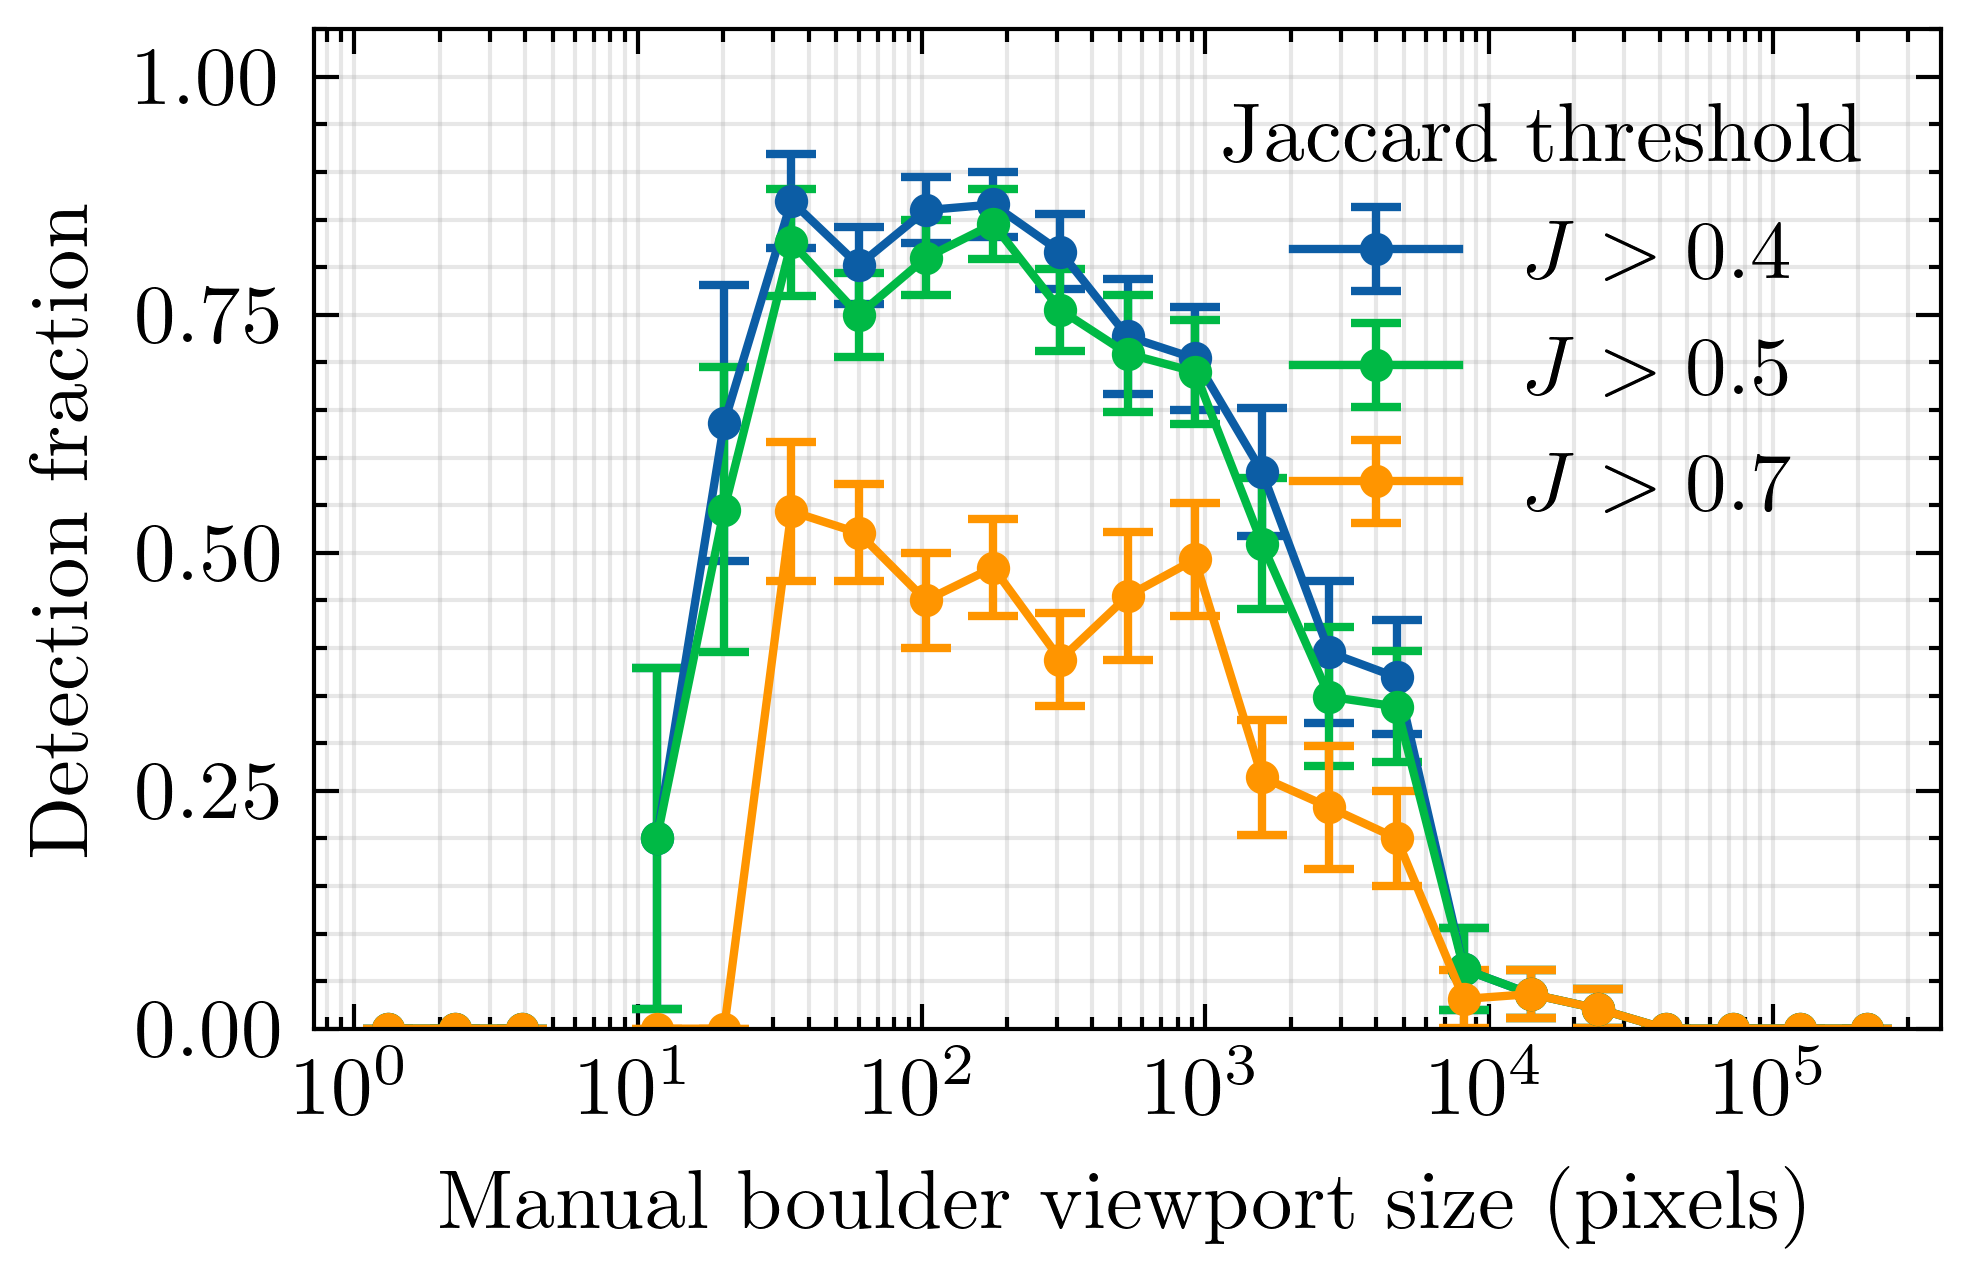

In [17]:
x = db_jaccard_agg["viewport_size"].to_numpy()
j = db_jaccard_agg["Jaccard_index"].to_numpy()

# n_bins = len(x) // 50

# # Equal-count bins
# bins = np.quantile(x, np.linspace(0, 1, n_bins + 1))

# # Remove duplicate edges (can occur if x has repeated values)
# bins = np.unique(bins)

# 8 logarithmic bins
bins = np.geomspace(1, x.max(), 24)

centres = np.sqrt(bins[:-1] * bins[1:])

total, _ = np.histogram(x, bins=bins)

thresholds = [0.4, 0.5, 0.7]

# plt.figure(figsize=(8, 5))

for thresh in thresholds:
    success, _ = np.histogram(x[j > thresh], bins=bins)

    rate = np.divide(
        success,
        total,
        out=np.full_like(success, np.nan, dtype=float),
        where=total > 0,
    )

    err = np.sqrt(rate * (1 - rate) / total)
    err[total == 0] = np.nan

    plt.errorbar(
        centres,
        rate,
        yerr=err,
        marker=".",
        capsize=3,
        label=f"$J > {thresh}$",
    )

plt.xscale("log")
plt.ylim(0, 1.05)
# plt.xlim(1, 512*512)
plt.xlabel("Manual boulder viewport size (pixels)")
plt.ylabel("Detection fraction")
plt.grid(True, which="both", alpha=0.3)
plt.legend(title="Jaccard threshold")
plt.savefig(".plots/S_from_manual_detection.png")
plt.show()


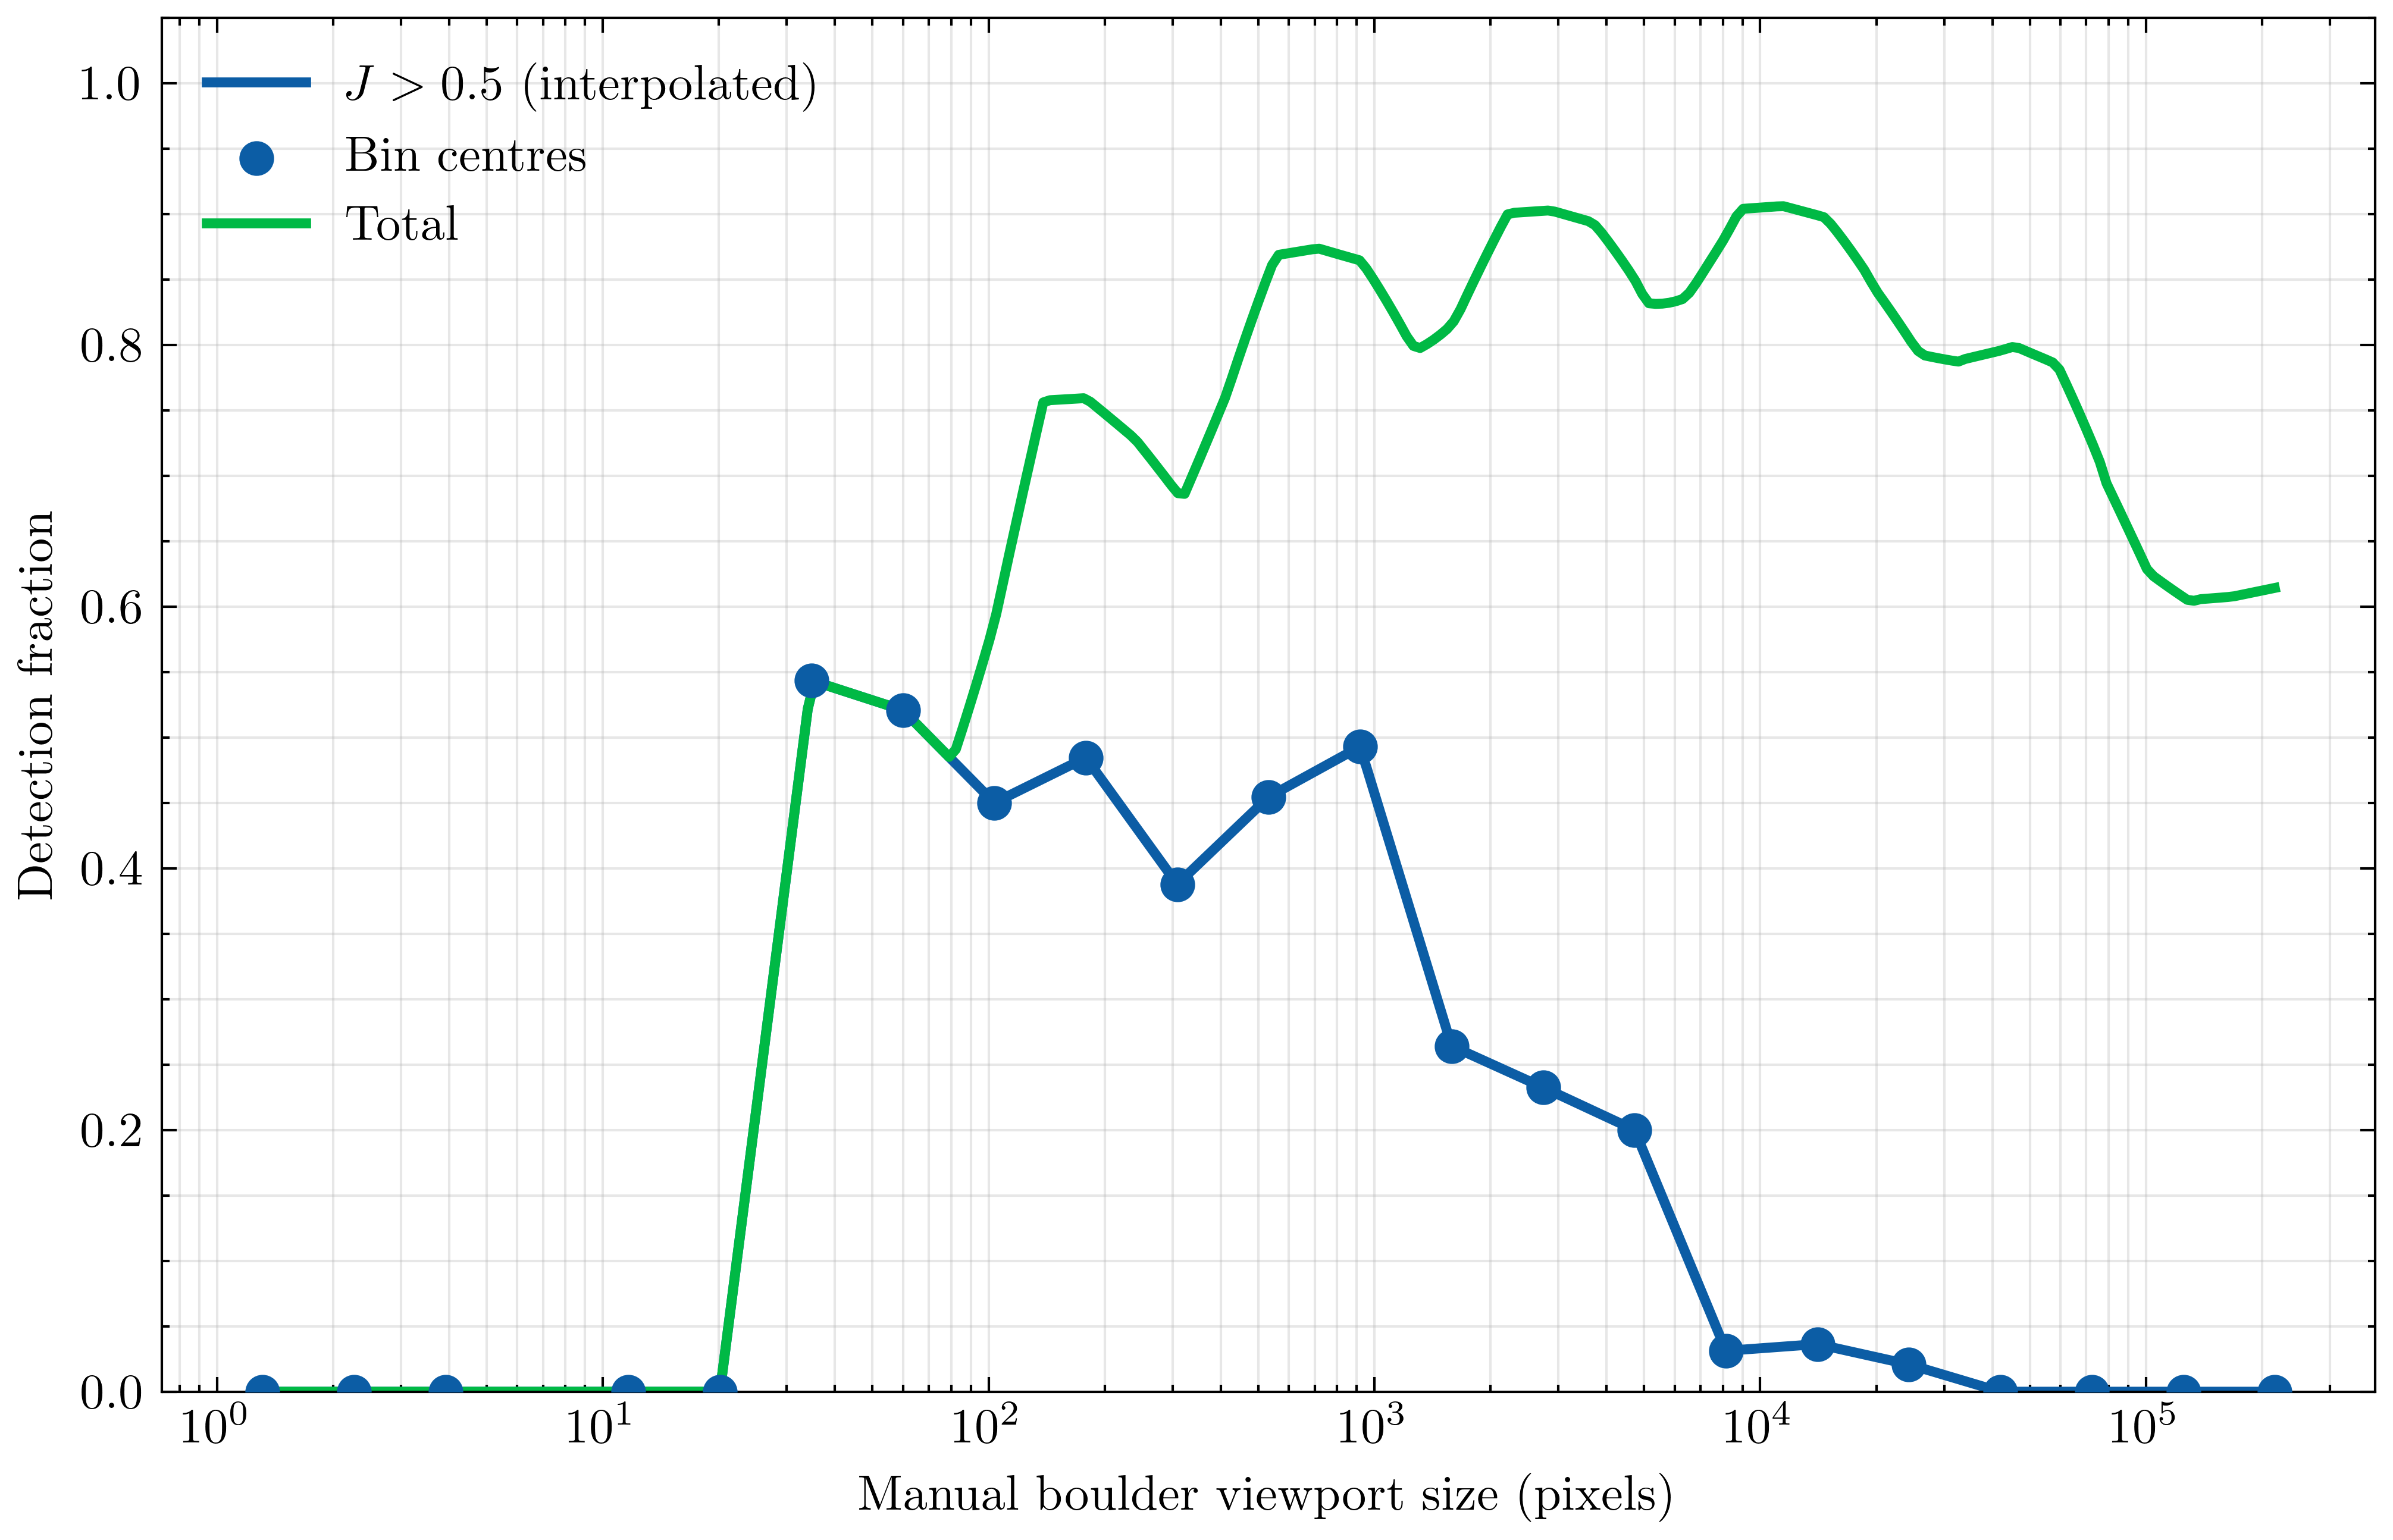

In [18]:
from scipy.interpolate import interp1d

total, _ = np.histogram(x, bins=bins)
success, _ = np.histogram(x[j > 0.7], bins=bins)

rate = np.divide(
    success,
    total,
    out=np.full_like(success, np.nan, dtype=float),
    where=total > 0,
)

# Keep only valid bins
mask = np.isfinite(rate)

# Interpolate in log-space
interp = interp1d(
    np.log10(centres[mask]),
    rate[mask],
    kind="linear",          # or "linear"
    bounds_error=False,
    fill_value=0.0,
)

x_smooth = np.geomspace(centres[mask].min(), centres[mask].max(), 300)
y_smooth = interp(np.log10(x_smooth))

plt.figure(figsize=(8,5))
plt.plot(x_smooth, y_smooth, lw=2, label=r"$J>0.5$ (interpolated)")
plt.scatter(centres, rate, color="C0", zorder=3, label="Bin centres")

total_s = 1 - np.prod([
            1 - interp(np.log10(x_smooth / (2 ** (2 * 4 - 2 * i)))) for i in range(5)
        ], axis=0)

plt.plot(x_smooth, total_s, lw=2, label=r"Total")

plt.xscale("log")
# plt.xlim(1, 512*512)
plt.ylim(0, 1.05)
plt.xlabel("Manual boulder viewport size (pixels)")
plt.ylabel("Detection fraction")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.show()

In [19]:
def approximate_S(J_threshold : float, samples : int = 1000):
    total, _ = np.histogram(x, bins=bins)
    success, _ = np.histogram(x[j > J_threshold], bins=bins)

    rate = np.divide(
        success,
        total,
        out=np.full_like(success, np.nan, dtype=float),
        where=total > 0,
    )

    err = np.sqrt(rate * (1 - rate) / total)
    err[total == 0] = np.nan

    # Keep only valid bins
    mask = np.isfinite(rate)

    interp_val = lambda alphas, values : interp1d(
            np.log10(centres[mask]),
            values[mask],
            kind="linear",          # or "linear"
            bounds_error=False,
            fill_value=np.nan,
        )(np.log10(alphas))

    x_smooth = np.geomspace(centres[mask].min(), centres[mask].max(), samples)

    return pl.DataFrame({
            "view_port_alpha" : x_smooth,
            "p_detection" : interp_val(x_smooth, rate),
            "p_err" :  interp_val(x_smooth, err),
            "n_samples" :  interp_val(x_smooth, total)
        }).with_columns(
            pl.lit(J_threshold).alias("J_threshold")
        )

In [20]:
df = pl.concat([approximate_S(j) for j in [0.2, 0.3, 0.5, 0.7, 0.9]])

df.write_parquet(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products\S_manual_interp.parquet")